<a href="https://colab.research.google.com/github/jooyongsim/deeplearning_SMWU_2026/blob/main/2026%EB%94%A5%EB%9F%AC%EB%8B%9D_Lab4_RL_Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RL Algorithms Tutorial: CartPole
## Vanilla Policy Gradient · DQN · A2C · PPO

### by Joo Yong Sim (2026.09.30) @ Sookmyung W. Univ, Mechanical System Eng.

Let's compare **four core RL algorithms** from scratch using PyTorch and Gymnasium's CartPole-v1.

| Section | Algorithm | Type | Key Idea |
|---------|-----------|------|----------|
| 1 | **REINFORCE** | On-policy, Policy Gradient | Monte Carlo return × log-prob |
| 2 | **DQN** | Off-policy, Value-based | Replay buffer + target network |
| 3 | **A2C** | On-policy, Actor-Critic | TD advantage reduces variance |
| 4 | **PPO** | On-policy, Actor-Critic | Clipped surrogate + GAE |

---
## 0. Setup & Imports

In [1]:
# Colab: install dependencies & virtual display for video recording
import sys
if 'google.colab' in sys.modules:
    !pip install -q gymnasium torch matplotlib numpy pyvirtualdisplay
    !apt-get install -y xvfb > /dev/null 2>&1
    from pyvirtualdisplay import Display
    display = Display(visible=0, size=(400, 300))
    display.start()
    print('Virtual display started.')

Virtual display started.


In [2]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np
import random
import collections
import os
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

import matplotlib.pyplot as plt
from IPython.display import Video, display as ipy_display

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Device: cpu


In [3]:
# --- Common helpers ---

VIDEO_DIR = './videos_tutorial'

def moving_average(data, window=20):
    """Simple moving average for smoothing reward curves."""
    ret = np.cumsum(data, dtype=float)
    ret[window:] = ret[window:] - ret[:-window]
    out = np.empty_like(ret)
    for i in range(len(ret)):
        w = min(i + 1, window)
        out[i] = ret[i] / w
    return out


def plot_returns(episode_returns, name, train_time, color='#4C72B0', window=20):
    """Plot raw + smoothed returns for a single algorithm."""
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(episode_returns, alpha=0.25, color=color, linewidth=0.5, label='Raw')
    ax.plot(moving_average(episode_returns, window), color=color, linewidth=2,
            label=f'Moving avg (w={window})')
    ax.set_title(f'{name} — Episode Returns  ({train_time:.1f}s on {DEVICE})')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Return')
    ax.legend()
    plt.tight_layout()
    plt.show()


def record_video(agent_fn, video_dir, name_prefix, num_episodes=1):
    """Record video of a trained agent."""
    os.makedirs(video_dir, exist_ok=True)
    env = gym.make('CartPole-v1', render_mode='rgb_array')
    env = RecordVideo(
        env,
        video_folder=video_dir,
        episode_trigger=lambda ep: True,
        name_prefix=name_prefix,
    )
    for ep in range(num_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action = agent_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
        print(f'[{name_prefix}] Episode {ep}: reward = {total_reward}')
    env.close()
    return os.path.join(video_dir, f'{name_prefix}-episode-0.mp4')


def show_video(path):
    """Display mp4 inline in Jupyter/Colab."""
    if os.path.exists(path):
        ipy_display(Video(path, embed=True, width=400))
    else:
        print(f'Video not found: {path}')

---
## 1. Vanilla Policy Gradient (REINFORCE)

### Core Idea
Directly parameterise a **policy** $\pi_\theta(a|s)$ and optimise it by gradient ascent on expected return:

$$\nabla_\theta J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta} \left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t \right]$$

where $G_t = \sum_{k=0}^{T-t} \gamma^k r_{t+k}$ is the **discounted Monte Carlo return**.

### Key Properties
- **On-policy**: must use trajectories from the current policy
- **High variance**: uses full episode returns → we normalise returns to reduce variance
- **No value function** (pure policy method)
- Simplest policy gradient algorithm — the foundation for A2C and PPO

In [21]:
# ===== REINFORCE =====

class ReinforcePolicy(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=-1)

def train_reinforce(policy, num_episodes=1000, gamma=0.99, lr=1e-3, print_interval=50):
    env = gym.make('CartPole-v1')
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    episode_returns = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        log_probs, rewards = [], []
        done = False

        # --- Collect one full episode ---
        while not done:
            state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE)
            probs = policy(state_t)
            dist = Categorical(probs)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))

            state, reward, terminated, truncated, _ = env.step(action.item())
            rewards.append(reward)
            done = terminated or truncated

        # --- Compute discounted returns G_t ---
        G = 0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns, dtype=torch.float32, device=DEVICE)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)  # normalise

        # --- Policy gradient loss: -log π(a|s) * G_t ---
        loss = torch.stack([-lp * Gt for lp, Gt in zip(log_probs, returns)]).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        episode_returns.append(sum(rewards))
        if (ep + 1) % print_interval == 0:
            avg = np.mean(episode_returns[-print_interval:])
            print(f'[REINFORCE] ep {ep+1:4d}  avg_reward: {avg:.1f}')

    env.close()
    return policy, episode_returns

In [5]:
policy = ReinforcePolicy(4,2,128).to(DEVICE)
t0 = time.time()
reinforce_policy, reinforce_returns = train_reinforce(policy,500)
reinforce_time = time.time() - t0
print(f'\n⏱ REINFORCE training time: {reinforce_time:.1f}s')

[REINFORCE] ep   50  avg_reward: 21.8
[REINFORCE] ep  100  avg_reward: 30.5
[REINFORCE] ep  150  avg_reward: 49.1
[REINFORCE] ep  200  avg_reward: 63.1
[REINFORCE] ep  250  avg_reward: 118.7
[REINFORCE] ep  300  avg_reward: 137.8
[REINFORCE] ep  350  avg_reward: 261.4
[REINFORCE] ep  400  avg_reward: 290.9
[REINFORCE] ep  450  avg_reward: 337.3
[REINFORCE] ep  500  avg_reward: 394.7
[REINFORCE] ep  550  avg_reward: 466.3
[REINFORCE] ep  600  avg_reward: 428.9
[REINFORCE] ep  650  avg_reward: 430.7
[REINFORCE] ep  700  avg_reward: 435.5
[REINFORCE] ep  750  avg_reward: 487.9
[REINFORCE] ep  800  avg_reward: 447.1
[REINFORCE] ep  850  avg_reward: 490.8
[REINFORCE] ep  900  avg_reward: 486.1
[REINFORCE] ep  950  avg_reward: 491.0
[REINFORCE] ep 1000  avg_reward: 461.8

⏱ REINFORCE training time: 295.9s


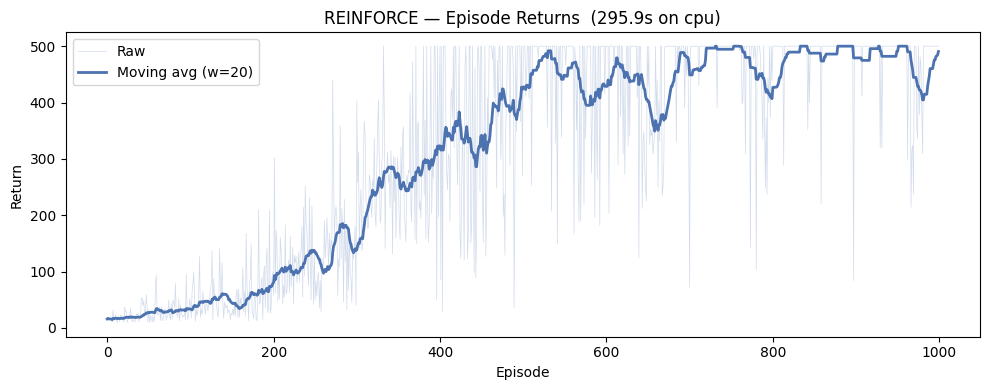

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos_tutorial folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.13/dist-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


[reinforce] Episode 0: reward = 500.0


/usr/local/lib/python3.13/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


In [6]:
# --- REINFORCE: plot + video ---
plot_returns(reinforce_returns, 'REINFORCE', reinforce_time, color='#4C72B0')

def reinforce_agent(obs):
    with torch.no_grad():
        probs = reinforce_policy(torch.tensor(obs, dtype=torch.float32, device=DEVICE))
        return probs.argmax().item()

reinforce_video = record_video(reinforce_agent, VIDEO_DIR, 'reinforce')
show_video(reinforce_video)

---
## 2. A2C (Advantage Actor-Critic)

### Core Idea
Combine a **policy** (actor) with a **value function** (critic). The critic provides a baseline that dramatically reduces variance compared to REINFORCE:

$$A(s,a) = r + \gamma V(s') - V(s) \quad \text{(TD advantage)}$$

$$\mathcal{L}_{\text{actor}} = -\log \pi_\theta(a|s) \cdot A(s,a)$$
$$\mathcal{L}_{\text{critic}} = A(s,a)^2$$

### Key Properties
- **On-policy**: updates happen step-by-step using the current policy's transitions
- **Lower variance** than REINFORCE because the advantage subtracts the value baseline
- **Higher bias** than REINFORCE (bootstrapping from V introduces bias)
- The "A" in A2C stands for "Advantage" — the key insight is using $A$ instead of raw $G_t$

In [7]:
# ===== A2C =====

class ActorNet(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x), dim=-1)


class CriticNet(nn.Module):
    def __init__(self, state_dim=4, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def train_a2c(num_episodes=1000, gamma=0.99, lr=1e-3, print_interval=50):
    env = gym.make('CartPole-v1')
    actor = ActorNet().to(DEVICE)
    critic = CriticNet().to(DEVICE)
    actor_optim = optim.Adam(actor.parameters(), lr=lr)
    critic_optim = optim.Adam(critic.parameters(), lr=lr)
    episode_returns = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0

        while not done:
            state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE)

            # --- Actor: sample action ---
            probs = actor(state_t)
            dist = Categorical(probs)
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            next_state_t = torch.tensor(next_state, dtype=torch.float32, device=DEVICE)

            # --- Critic: compute TD advantage ---
            value = critic(state_t)
            with torch.no_grad():
                next_value = critic(next_state_t)
            td_target = reward + gamma * next_value * (1 - int(done))
            advantage = (td_target - value).detach()

            # --- Actor loss ---
            actor_loss = -log_prob * advantage
            actor_optim.zero_grad()
            actor_loss.backward()
            actor_optim.step()

            # --- Critic loss ---
            critic_loss = F.mse_loss(value, td_target.detach())
            critic_optim.zero_grad()
            critic_loss.backward()
            critic_optim.step()

            state = next_state
            ep_reward += reward

        episode_returns.append(ep_reward)
        if (ep + 1) % print_interval == 0:
            avg = np.mean(episode_returns[-print_interval:])
            print(f'[A2C] ep {ep+1:4d}  avg_reward: {avg:.1f}')

    env.close()
    return actor, critic, episode_returns

In [8]:
t0 = time.time()
a2c_actor, a2c_critic, a2c_returns = train_a2c()
a2c_time = time.time() - t0
print(f'\n⏱ A2C training time: {a2c_time:.1f}s')

[A2C] ep   50  avg_reward: 12.3
[A2C] ep  100  avg_reward: 11.5
[A2C] ep  150  avg_reward: 13.6
[A2C] ep  200  avg_reward: 32.4
[A2C] ep  250  avg_reward: 52.4
[A2C] ep  300  avg_reward: 80.1
[A2C] ep  350  avg_reward: 81.3
[A2C] ep  400  avg_reward: 111.2
[A2C] ep  450  avg_reward: 183.1
[A2C] ep  500  avg_reward: 155.4
[A2C] ep  550  avg_reward: 202.5
[A2C] ep  600  avg_reward: 84.1
[A2C] ep  650  avg_reward: 229.9
[A2C] ep  700  avg_reward: 266.5
[A2C] ep  750  avg_reward: 143.2
[A2C] ep  800  avg_reward: 9.4
[A2C] ep  850  avg_reward: 9.4
[A2C] ep  900  avg_reward: 9.4
[A2C] ep  950  avg_reward: 11.4
[A2C] ep 1000  avg_reward: 9.5

⏱ A2C training time: 220.4s


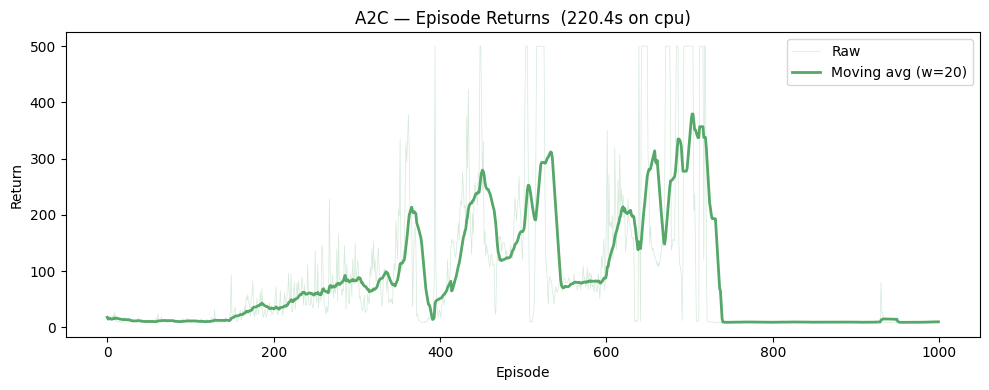

/usr/local/lib/python3.13/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos_tutorial folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[a2c] Episode 0: reward = 10.0


In [9]:
# --- A2C: plot + video ---
plot_returns(a2c_returns, 'A2C', a2c_time, color='#55A868')

def a2c_agent(obs):
    with torch.no_grad():
        probs = a2c_actor(torch.tensor(obs, dtype=torch.float32, device=DEVICE))
        return probs.argmax().item()

a2c_video = record_video(a2c_agent, VIDEO_DIR, 'a2c')
show_video(a2c_video)

---
## 3. PPO (Proximal Policy Optimization)

### Core Idea
PPO improves upon A2C by allowing **multiple epochs of updates** on the same batch of data, while preventing the policy from changing too much via a **clipped surrogate objective**:

$$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{\text{old}}}(a_t|s_t)}$$

$$\mathcal{L}^{\text{CLIP}} = \mathbb{E}_t \left[ \min\left( r_t(\theta) \hat{A}_t, \; \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

### GAE (Generalised Advantage Estimation)
Instead of 1-step TD advantage, PPO uses GAE which interpolates between Monte Carlo and TD:

$$\hat{A}_t = \sum_{l=0}^{T-t} (\gamma \lambda)^l \delta_{t+l}, \quad \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

### Key Properties
- **On-policy** but gets **multiple gradient steps** from the same rollout (more sample efficient than A2C)
- The **clip** keeps the new policy close to the old → stable training
- Currently the most widely used RL algorithm (used in RLHF for LLMs)

In [10]:
# ===== PPO =====

class PPOActorCritic(nn.Module):
    """Shared feature extractor with separate actor and critic heads."""
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
        )
        self.actor_head = nn.Linear(hidden, action_dim)
        self.critic_head = nn.Linear(hidden, 1)

    def forward(self, x):
        feat = self.shared(x)
        policy = F.softmax(self.actor_head(feat), dim=-1)
        value = self.critic_head(feat)
        return policy, value

    def act(self, state):
        state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE)
        probs, value = self.forward(state_t)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action), value


def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    """Compute Generalised Advantage Estimation."""
    advantages = []
    gae = 0
    for t in reversed(range(len(rewards))):
        delta = rewards[t] + gamma * values[t + 1] * (1 - dones[t]) - values[t]
        gae = delta + gamma * lam * (1 - dones[t]) * gae
        advantages.insert(0, gae)
    advantages = torch.tensor(advantages, dtype=torch.float32, device=DEVICE)
    returns = advantages + torch.tensor(values[:-1], dtype=torch.float32, device=DEVICE)
    return advantages, returns


def train_ppo(num_episodes=5000, gamma=0.99, lam=0.95, lr=3e-4,
              clip_eps=0.2, ppo_epochs=4, rollout_len=128,
              print_interval=50):
    env = gym.make('CartPole-v1')
    model = PPOActorCritic().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    episode_returns = []
    ep_reward = 0
    state, _ = env.reset()

    while len(episode_returns) < num_episodes:
        # --- Collect rollout ---
        states, actions, log_probs_old, rewards, dones, values = [], [], [], [], [], []

        for _ in range(rollout_len):
            action, log_prob, value = model.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            states.append(state)
            actions.append(action)
            log_probs_old.append(log_prob.detach())
            rewards.append(reward)
            dones.append(float(done))
            values.append(value.item())

            ep_reward += reward
            state = next_state

            if done:
                episode_returns.append(ep_reward)
                if len(episode_returns) % print_interval == 0:
                    avg = np.mean(episode_returns[-print_interval:])
                    print(f'[PPO] ep {len(episode_returns):4d}  avg_reward: {avg:.1f}')
                ep_reward = 0
                state, _ = env.reset()
                if len(episode_returns) >= num_episodes:
                    break

        # Bootstrap value for the last state
        with torch.no_grad():
            _, bootstrap_val = model(torch.tensor(state, dtype=torch.float32, device=DEVICE))
        values.append(bootstrap_val.item())

        # --- GAE ---
        advantages, returns = compute_gae(rewards, values, dones, gamma, lam)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # Convert to tensors
        states_t = torch.tensor(np.array(states), dtype=torch.float32, device=DEVICE)
        actions_t = torch.tensor(actions, dtype=torch.long, device=DEVICE)
        log_probs_old_t = torch.stack(log_probs_old)

        # --- PPO update: multiple epochs on same data ---
        for _ in range(ppo_epochs):
            probs, values_pred = model(states_t)
            dist = Categorical(probs)
            log_probs_new = dist.log_prob(actions_t)

            # Importance sampling ratio
            ratio = torch.exp(log_probs_new - log_probs_old_t)

            # Clipped surrogate objective
            surr1 = ratio * advantages
            surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * advantages
            actor_loss = -torch.min(surr1, surr2).mean()

            # Critic loss
            critic_loss = F.mse_loss(values_pred.squeeze(), returns)

            # Entropy bonus for exploration
            entropy = dist.entropy().mean()

            loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()

    env.close()
    return model, episode_returns[:num_episodes]

In [ ]:
t0 = time.time()
ppo_model, ppo_returns = train_ppo()
ppo_time = time.time() - t0
print(f'\n⏱ PPO training time: {ppo_time:.1f}s')

[PPO] ep   50  avg_reward: 17.7
[PPO] ep  100  avg_reward: 24.7
[PPO] ep  150  avg_reward: 23.5
[PPO] ep  200  avg_reward: 28.2
[PPO] ep  250  avg_reward: 34.3
[PPO] ep  300  avg_reward: 43.5
[PPO] ep  350  avg_reward: 46.6
[PPO] ep  400  avg_reward: 63.5
[PPO] ep  450  avg_reward: 86.4
[PPO] ep  500  avg_reward: 98.4
[PPO] ep  550  avg_reward: 143.4
[PPO] ep  600  avg_reward: 171.4
[PPO] ep  650  avg_reward: 192.3
[PPO] ep  700  avg_reward: 200.7
[PPO] ep  750  avg_reward: 121.5
[PPO] ep  800  avg_reward: 161.1
[PPO] ep  850  avg_reward: 211.2
[PPO] ep  900  avg_reward: 180.2
[PPO] ep  950  avg_reward: 155.1
[PPO] ep 1000  avg_reward: 184.7
[PPO] ep 1050  avg_reward: 155.8
[PPO] ep 1100  avg_reward: 112.7
[PPO] ep 1150  avg_reward: 111.3
[PPO] ep 1200  avg_reward: 160.6
[PPO] ep 1250  avg_reward: 142.1
[PPO] ep 1300  avg_reward: 190.6
[PPO] ep 1350  avg_reward: 194.5
[PPO] ep 1400  avg_reward: 200.7
[PPO] ep 1450  avg_reward: 239.8
[PPO] ep 1500  avg_reward: 213.0
[PPO] ep 1550  avg_r

In [ ]:
# --- PPO: plot + video ---
plot_returns(ppo_returns, 'PPO', ppo_time, color='#C44E52')

def ppo_agent(obs):
    with torch.no_grad():
        probs, _ = ppo_model(torch.tensor(obs, dtype=torch.float32, device=DEVICE))
        return probs.argmax().item()

ppo_video = record_video(ppo_agent, VIDEO_DIR, 'ppo')
show_video(ppo_video)

---
## 4. DQN (Deep Q-Network)

### Core Idea
Approximate the **action-value function** $Q(s,a)$ with a neural network, then act greedily:

$$\mathcal{L} = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q_{\text{target}}(s',a') - Q(s,a) \right)^2 \right]$$

### Key Innovations
- **Experience replay** $\mathcal{D}$: stores past transitions, breaks temporal correlation, reuses data (sample efficient)
- **Target network** $Q_{\text{target}}$: a periodically-copied frozen copy of Q → stabilises training
- **$\varepsilon$-greedy exploration**: with probability $\varepsilon$ take a random action, otherwise $\arg\max_a Q(s,a)$

### Key Properties
- **Off-policy**: can learn from old transitions stored in the buffer
- **Value-based**: no explicit policy network — the policy is implicit (argmax Q)
- Only works for **discrete** action spaces

In [ ]:
# ===== DQN =====

class QNet(nn.Module):
    def __init__(self, state_dim=4, action_dim=2, hidden=128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = collections.deque(maxlen=capacity)

    def put(self, transition):
        self.buffer.append(transition)

    def sample(self, n):
        batch = random.sample(self.buffer, n)
        s, a, r, s2, done = zip(*batch)
        return (
            torch.tensor(np.array(s), dtype=torch.float32, device=DEVICE),
            torch.tensor(a, dtype=torch.long, device=DEVICE).unsqueeze(1),
            torch.tensor(r, dtype=torch.float32, device=DEVICE).unsqueeze(1),
            torch.tensor(np.array(s2), dtype=torch.float32, device=DEVICE),
            torch.tensor(done, dtype=torch.float32, device=DEVICE).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


def train_dqn(num_episodes=1000, gamma=0.99, lr=1e-3, batch_size=64,
              buffer_size=50000, warmup=2000, eps_start=1.0,
              eps_end=0.01, eps_decay=500, target_update=20,
              print_interval=50):
    env = gym.make('CartPole-v1')
    q = QNet().to(DEVICE)
    q_target = QNet().to(DEVICE)
    q_target.load_state_dict(q.state_dict())

    optimizer = optim.Adam(q.parameters(), lr=lr)
    memory = ReplayBuffer(buffer_size)
    episode_returns = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        done = False
        ep_reward = 0

        # epsilon schedule: linear decay
        epsilon = max(eps_end, eps_start - (eps_start - eps_end) * ep / eps_decay)

        while not done:
            # --- ε-greedy action selection ---
            if random.random() < epsilon:
                action = random.randint(0, 1)
            else:
                with torch.no_grad():
                    state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE)
                    action = q(state_t).argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            done_mask = 0.0 if done else 1.0
            memory.put((state, action, reward / 100.0, next_state, done_mask))

            state = next_state
            ep_reward += reward

        # --- Train on mini-batch ---
        if len(memory) >= warmup:
            for _ in range(10):
                s, a, r, s2, d = memory.sample(batch_size)
                q_val = q(s).gather(1, a)
                with torch.no_grad():
                    max_q_next = q_target(s2).max(1, keepdim=True)[0]
                    target = r + gamma * max_q_next * d
                loss = F.smooth_l1_loss(q_val, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # --- Periodically sync target network ---
        if (ep + 1) % target_update == 0:
            q_target.load_state_dict(q.state_dict())

        episode_returns.append(ep_reward)
        if (ep + 1) % print_interval == 0:
            avg = np.mean(episode_returns[-print_interval:])
            print(f'[DQN] ep {ep+1:4d}  avg_reward: {avg:.1f}  eps: {epsilon:.3f}')

    env.close()
    return q, episode_returns

In [ ]:
t0 = time.time()
dqn_model, dqn_returns = train_dqn()
dqn_time = time.time() - t0
print(f'\n⏱ DQN training time: {dqn_time:.1f}s')

In [ ]:
# --- DQN: plot + video ---
plot_returns(dqn_returns, 'DQN', dqn_time, color='#DD8452')

def dqn_agent(obs):
    with torch.no_grad():
        q_vals = dqn_model(torch.tensor(obs, dtype=torch.float32, device=DEVICE))
        return q_vals.argmax().item()

dqn_video = record_video(dqn_agent, VIDEO_DIR, 'dqn')
show_video(dqn_video)

---
## 5. Comparison

In [ ]:
COLORS = {'REINFORCE': '#4C72B0', 'DQN': '#DD8452', 'A2C': '#55A868', 'PPO': '#C44E52'}
results = {
    'REINFORCE': reinforce_returns,
    'DQN': dqn_returns,
    'A2C': a2c_returns,
    'PPO': ppo_returns,
}
window = 20

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Raw returns ---
for name, rets in results.items():
    axes[0].plot(rets, alpha=0.3, linewidth=0.5, color=COLORS[name])
axes[0].set_title('Raw Episode Returns')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Return')
axes[0].legend(results.keys())

# --- Smoothed (moving average) ---
for name, rets in results.items():
    axes[1].plot(moving_average(rets, window), linewidth=1.5, color=COLORS[name])
axes[1].set_title(f'Smoothed Returns (window={window})')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Return')
axes[1].legend(results.keys())

plt.tight_layout()
plt.savefig('./comparison_4_algorithms.png', dpi=150)
plt.show()

In [ ]:
# --- Training time comparison ---
names = ['REINFORCE', 'DQN', 'A2C', 'PPO']
times = [reinforce_time, dqn_time, a2c_time, ppo_time]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, times, color=[COLORS[n] for n in names])
ax.set_ylabel('Training Time (seconds)')
ax.set_title(f'Training Time Comparison — 1000 episodes on {DEVICE}')
for bar, t in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{t:.1f}s', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('./timing_comparison.png', dpi=150)
plt.show()

print(f'\nDevice: {DEVICE}')
for n, t in zip(names, times):
    print(f'  {n:12s}: {t:6.1f}s')

### Summary

| | REINFORCE | DQN | A2C | PPO |
|---|---|---|---|---|
| **Type** | Policy Gradient | Value-based | Actor-Critic | Actor-Critic |
| **On/Off-policy** | On | Off | On | On |
| **Update** | Episode-end | Every step (batch) | Every step | Every rollout (multi-epoch) |
| **Variance** | High | Low (replay) | Medium | Low (GAE + clip) |
| **Sample efficiency** | Low | High (replay) | Low | Medium |
| **Stability** | Unstable | Moderate | Moderate | High |
| **Continuous actions?** | Yes | No (discrete only) | Yes | Yes |